In [7]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("/sujin/PycharmProjects/DomainReComb")

import torch
import faiss
import json
from src.DomainSearch.utils.generate_lmdb import get_value
import numpy as np
import random

from tqdm import tqdm
from src.DomainSearch.utils.others import setup_seed
from src.DomainSearch.models.ted.ted_domain_model import TedDomainModel
from src.DomainSearch.utils.mpr import MultipleProcessRunnerSimplifier

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Foldseek Clusters


In [8]:
tsv_list = [
    "train_20260215.tsv",
    "valid_20260215.tsv",
    "test_20260215.tsv"
]

cluster2member = {}

for tsv in tsv_list:
    path = f"/sujin/Datasets/TED/splits/{tsv}"
    with open(path, "r") as r:
        for line in tqdm(r):
            rep_id, mem_id = line.strip().split("\t")
            if rep_id not in cluster2member:
                cluster2member[rep_id] = []

            cluster2member[rep_id].append(mem_id)

92562657it [01:14, 1239295.92it/s]
34296it [00:00, 383255.98it/s]
49679it [00:00, 497812.38it/s]


Total number of clusters: 1,957,679
Total number of members: 92,646,632

Statistics:
  Mean members per cluster: 47.32
  Median: 2
  Min: 1
  Max: 531,447
  Std: 980.01

Cluster distribution by size range:
     Singleton:  953,212 (48.69%)
           2-5:  539,107 (27.54%)
          6-10:  151,059 ( 7.72%)
         11-50:  199,821 (10.21%)
        51-100:   42,415 ( 2.17%)
       101-500:   50,046 ( 2.56%)
      501-1000:    9,623 ( 0.49%)
         >1000:   12,396 ( 0.63%)


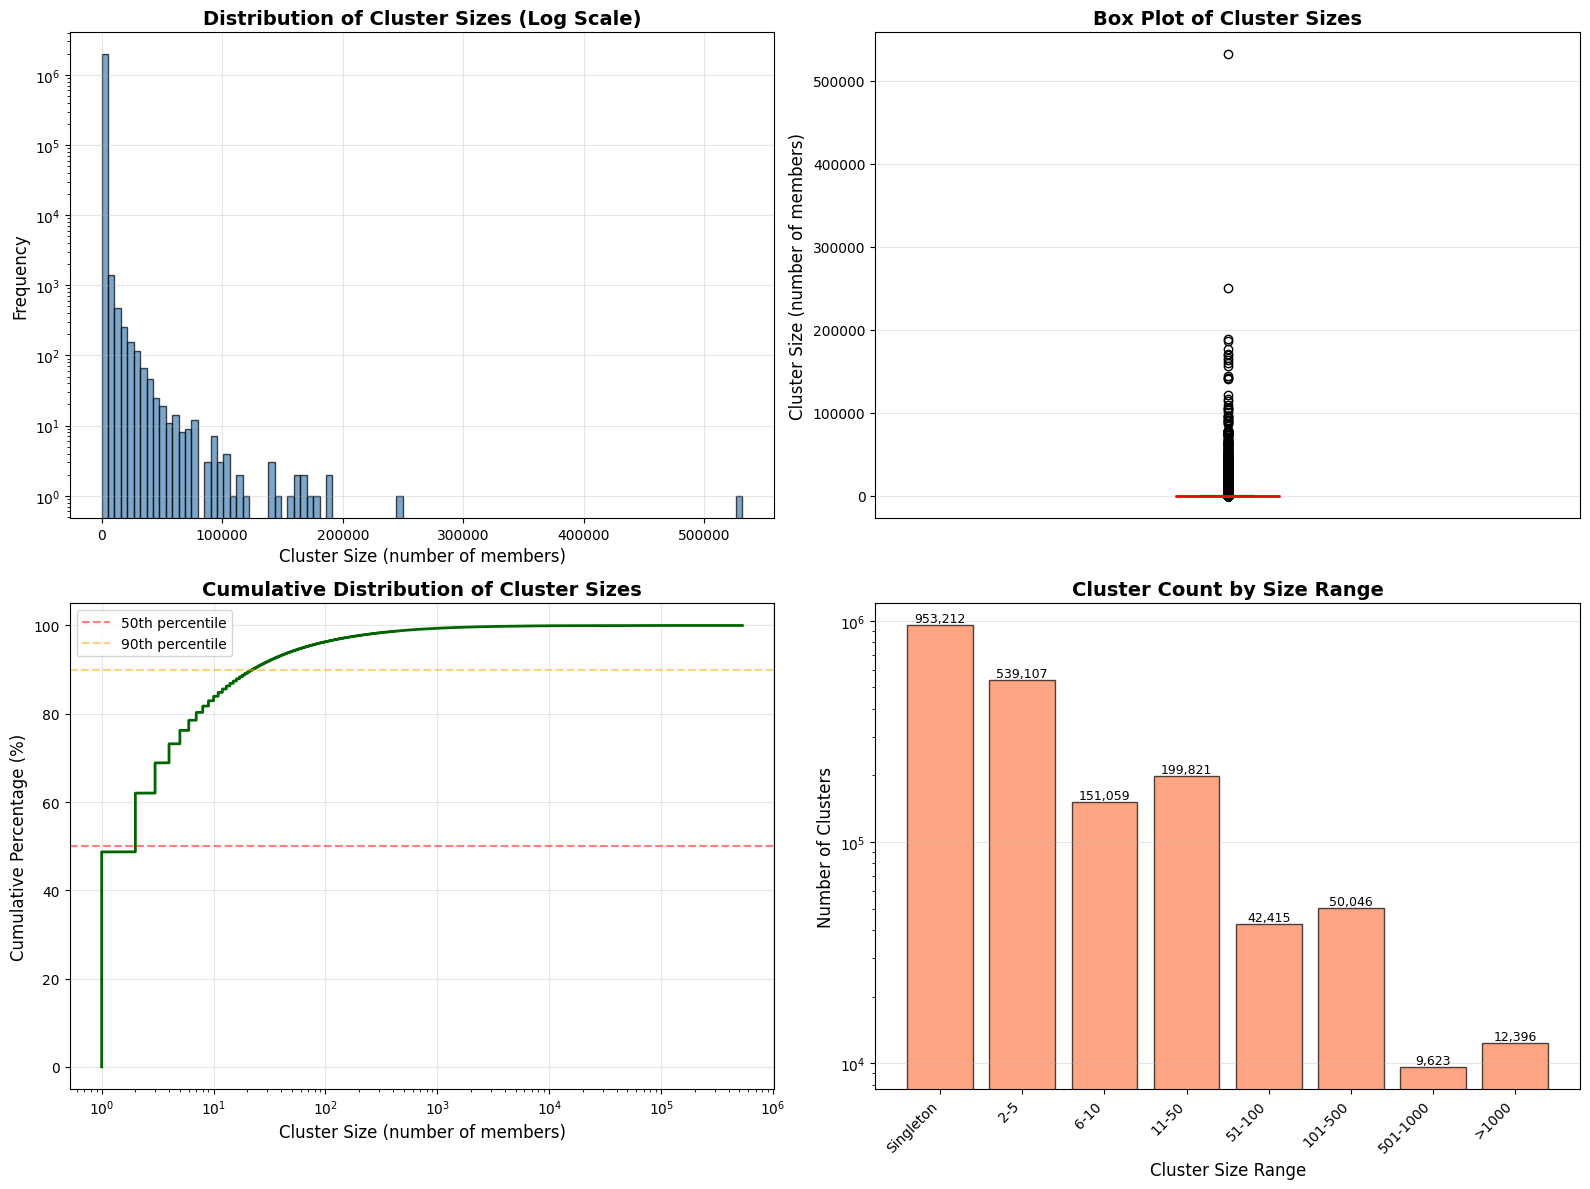


Key percentiles:
  50th percentile: 2
  75th percentile: 5
  90th percentile: 22
  95th percentile: 64
  99th percentile: 577


In [11]:
import matplotlib.pyplot as plt
from collections import Counter

# Analyze the distribution of member counts in clusters
member_counts = [len(members) for members in cluster2member.values()]

print(f"Total number of clusters: {len(cluster2member):,}")
print(f"Total number of members: {sum(member_counts):,}")
print(f"\nStatistics:")
print(f"  Mean members per cluster: {np.mean(member_counts):.2f}")
print(f"  Median: {np.median(member_counts):.0f}")
print(f"  Min: {min(member_counts)}")
print(f"  Max: {max(member_counts):,}")
print(f"  Std: {np.std(member_counts):.2f}")

# Count clusters in different size ranges
size_ranges = [
    (1, 1, "Singleton"),
    (2, 5, "2-5"),
    (6, 10, "6-10"),
    (11, 50, "11-50"),
    (51, 100, "51-100"),
    (101, 500, "101-500"),
    (501, 1000, "501-1000"),
    (1001, float('inf'), ">1000")
]

print(f"\nCluster distribution by size range:")
for min_size, max_size, label in size_ranges:
    count = sum(1 for c in member_counts if min_size <= c <= max_size)
    percentage = count / len(member_counts) * 100
    print(f"  {label:>12}: {count:>8,} ({percentage:>5.2f}%)")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogram - overall distribution (log scale)
ax1 = axes[0, 0]
ax1.hist(member_counts, bins=100, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Cluster Size (number of members)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Cluster Sizes (Log Scale)', fontsize=14, fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# 2. Box plot - statistical features
ax2 = axes[0, 1]
bp = ax2.boxplot(member_counts, vert=True, patch_artist=True, 
                  boxprops=dict(facecolor='lightblue', alpha=0.7),
                  medianprops=dict(color='red', linewidth=2),
                  whiskerprops=dict(linewidth=1.5),
                  capprops=dict(linewidth=1.5))
ax2.set_ylabel('Cluster Size (number of members)', fontsize=12)
ax2.set_title('Box Plot of Cluster Sizes', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks([])

# 3. Cumulative distribution
ax3 = axes[1, 0]
sorted_counts = np.sort(member_counts)
cumulative = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts) * 100
ax3.plot(sorted_counts, cumulative, linewidth=2, color='darkgreen')
ax3.set_xlabel('Cluster Size (number of members)', fontsize=12)
ax3.set_ylabel('Cumulative Percentage (%)', fontsize=12)
ax3.set_title('Cumulative Distribution of Cluster Sizes', fontsize=14, fontweight='bold')
ax3.set_xscale('log')
ax3.grid(True, alpha=0.3)
ax3.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50th percentile')
ax3.axhline(y=90, color='orange', linestyle='--', alpha=0.5, label='90th percentile')
ax3.legend()

# 4. Bar chart - distribution by size range
ax4 = axes[1, 1]
range_labels = [label for _, _, label in size_ranges]
range_counts = []
for min_size, max_size, _ in size_ranges:
    count = sum(1 for c in member_counts if min_size <= c <= max_size)
    range_counts.append(count)

bars = ax4.bar(range(len(range_labels)), range_counts, color='coral', alpha=0.7, edgecolor='black')
ax4.set_xlabel('Cluster Size Range', fontsize=12)
ax4.set_ylabel('Number of Clusters', fontsize=12)
ax4.set_title('Cluster Count by Size Range', fontsize=14, fontweight='bold')
ax4.set_xticks(range(len(range_labels)))
ax4.set_xticklabels(range_labels, rotation=45, ha='right')
ax4.set_yscale('log')
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, range_counts)):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{count:,}',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Output key percentiles
percentiles = [50, 75, 90, 95, 99]
print(f"\nKey percentiles:")
for p in percentiles:
    value = np.percentile(member_counts, p)
    print(f"  {p}th percentile: {value:.0f}")

# Sampling Strategy for Retrieval Database

In [14]:
def get_sampling_size(cluster_size):
    """Sampling strategy A: High coverage for retrieval tasks."""
    if cluster_size <= 10:
        return cluster_size
    elif cluster_size <= 50:
        return 10
    elif cluster_size <= 100:
        return 20
    elif cluster_size <= 500:
        return 50
    elif cluster_size <= 1000:
        return 100
    else:
        return 200


setup_seed(20000812)

sampled_proteins = []
total_before = 0
total_after = 0

print("Sampling proteins from clusters...")
for rep_id, mem_list in tqdm(cluster2member.items()):
    cluster_size = len(mem_list)
    sampling_size = get_sampling_size(cluster_size)
    
    # Sample members
    members = mem_list if sampling_size >= cluster_size else random.sample(mem_list, sampling_size)
    
    # Store with metadata
    sampled_proteins += members
    
    total_before += cluster_size
    total_after += len(members)

print(f"\nTotal proteins before: {total_before:,}")
print(f"Total proteins after: {total_after:,}")
print(f"Overall sampling rate: {total_after/total_before*100:.2f}%")

Sampling proteins from clusters...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1957679/1957679 [00:06<00:00, 295446.46it/s]


Total proteins before: 92,646,632
Total proteins after: 12,451,531
Overall sampling rate: 13.44%


In [ ]:
# Save sampled proteins
output_path = "/sujin/Datasets/TED/embedding/afdb_cluster/sampled_proteins_retrieval.tsv"

print(f"Saving to {output_path}...")
with open(output_path, 'w') as f:
    f.write("protein_id\tcluster_id\tcluster_size\n")
    for item in tqdm(sampled_proteins):
        f.write(f"{item['protein_id']}\t{item['cluster_id']}\t{item['cluster_size']}\n")

print(f"Saved {len(sampled_proteins):,} proteins")

In [9]:
for rep_id, mem_list in tqdm(cluster2member.items()):
    pass

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1957679/1957679 [00:00<00:00, 3653019.82it/s]


# Sample 20M proteins

In [ ]:
setup_seed(20000812)

k = 5
final_proteins = []
for rep_id, mem_list in tqdm(cluster2member.items()):
    # Sample k members for each cluster
    if len(mem_list) < k:
        members = mem_list

    else:
        members = random.sample(mem_list, k)

    final_proteins += members

print(len(final_proteins))

In [53]:
sorted_proteins = sorted(final_proteins)

plddt_lmdb = "/sujin/Datasets/LMDB/afdb_plddt"
invalid_proteins = []
for uniprot_id in tqdm(sorted_proteins):
    plddt_dict = json.loads(get_value(plddt_lmdb, uniprot_id))
    plddt_list = json.loads(f"[{plddt_dict['plddt']}]")
    avg_plddt = np.mean(plddt_list)

    if avg_plddt < 70:
        invalid_proteins.append(uniprot_id)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4840599/4840599 [16:10<00:00, 4985.97it/s]


In [59]:
uniprot_id = "A0A1Q8BGE2"
print(uniprot_id in set(final_proteins))

False


In [46]:
assert len(set(final_proteins)) == len(final_proteins)

In [34]:
seg_path = "/sujin/Datasets/TED/sa_segments_ge2.tsv"
uniprot2seqs = {}
with open(seg_path, "r") as r:
    for line in tqdm(r):
        uniprot_id, sa_seg = line.strip().split("\t")
        if uniprot_id not in uniprot2seqs:
            uniprot2seqs[uniprot_id] = []

        uniprot2seqs[uniprot_id].append(sa_seg)

265616762it [09:26, 469156.19it/s]


In [48]:
save_path = "/sujin/Datasets/TED/embedding/afdb_cluster/sampled_proteins.tsv"
cnt = 0
with open(save_path, "w") as w:
    for uniprot_id in tqdm(final_proteins):
        for sa_seg in uniprot2seqs[uniprot_id]:
            w.write(f"{uniprot_id}\t{sa_seg}\n")
            cnt += 1

print(cnt)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4840599/4840599 [00:14<00:00, 330302.88it/s]

11771745


In [53]:
# Generate embeddings
path = "/sujin/Datasets/TED/embedding/afdb_cluster/sampled_proteins.tsv"
sa_segs = []
with open(path, "r") as r:
    for line in tqdm(r):
        uniprot_id, sa_seg = line.strip().split("\t")
        sa_segs.append(sa_seg)

print(len(sa_segs))

11771745


In [36]:
model_tag = "TED-650M-plddt70"

config = {
    "config_path": f"/sujin/Models/TED/{model_tag}",
    "from_checkpoint": f"/sujin/Models/TED/{model_tag}/{model_tag}.pt",
}

device = "cuda"
model = TedDomainModel(**config)

No lr_scheduler_kwargs provided. The default learning rate is 0.
No optimizer_kwargs provided. The default optimizer is AdamW.
Some weights of the model checkpoint were not used: ['esm.embeddings.position_ids']


In [1]:
def do(process_id, idx, item, writer):
    i, sa_seg = item
    if model.device == "cpu":
        device = f"cuda:{process_id}"
        model.to(device)

    with torch.no_grad():
        key_repr = model.get_key_repr(sa_seg)
        embeddings[i] = key_repr

embedding_path = f"/sujin/Datasets/TED/embedding/afdb_cluster/embeddings_{len(sa_segs)}.npy"
embeddings = np.memmap(embedding_path, dtype="float32", mode="write", shape=(len(sa_segs), 1280))

inputs = [[i, sa_seg] for i, sa_seg in enumerate(sa_segs)]

mprs = MultipleProcessRunnerSimplifier(data=inputs, do=do, n_process=1)
mprs.run()

NameError: name 'sa_segs' is not defined

In [37]:
# embedding_path = f"/sujin/Datasets/TED/embedding/afdb_cluster/embeddings_11771745.npy"
# embeddings = np.memmap(embedding_path, dtype="float32", mode="r", shape=(11771745, 1280))

embedding_path = f"/sujin/Datasets/TED/embedding/afdb_cluster/query_embeddings_11771745.npy"
query_embeddings = np.memmap(embedding_path, dtype="float32", mode="r", shape=(11771745, 1280))

embedding_path = f"/sujin/Datasets/TED/embedding/afdb_cluster/key_embeddings_11771745.npy"
key_embeddings = np.memmap(embedding_path, dtype="float32", mode="r", shape=(11771745, 1280))

In [7]:
for embedding in tqdm(query_embeddings):
    assert embedding.sum() != 0

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11771745/11771745 [03:51<00:00, 50767.61it/s]


# Start Retrieval

In [60]:
# Load index
# index_path = f"/sujin/Datasets/TED/embedding/afdb_cluster/embeddings.index"
# index = faiss.read_index(index_path)
# index.metric_type = faiss.METRIC_INNER_PRODUCT
# index.nprobe = 1000
# res = faiss.StandardGpuResources()
# index = faiss.index_cpu_to_gpu(res, 0, index)

index_path = f"/sujin/Datasets/TED/embedding/afdb_cluster/embeddings.index"
index = faiss.read_index(index_path)
index.metric_type = faiss.METRIC_INNER_PRODUCT
index.nprobe = 1000

In [38]:
model_tag = "TED-650M-plddt70"

config = {
    "config_path": f"/sujin/Models/TED/{model_tag}",
    "from_checkpoint": f"/sujin/Models/TED/{model_tag}/{model_tag}.pt",
}

device = "cuda"
model = TedDomainModel(**config)
model = model.to(device)

In [3]:
seg_path = "/sujin/Datasets/TED/sa_segments_ge2.tsv"
uniprot2idx = {}
idx2uniprot = {}
idx2seg = {}
seg2idx = {}
with open(seg_path, "r") as r:
    for line in tqdm(r):
        uniprot_id, sa_seg = line.strip().split("\t")
        idx = seg2idx.get(sa_seg, len(seg2idx))
        seg2idx[sa_seg] = idx
        idx2seg[idx] = sa_seg
        uniprot2idx[uniprot_id] = uniprot2idx.get(uniprot_id, []) + [idx]
        idx2uniprot[idx] = idx2uniprot.get(idx, []) + [uniprot_id]

265616762it [17:55, 246886.85it/s]


In [77]:
# Load protein pool
protein_path = "/sujin/Datasets/TED/embedding/afdb_cluster/sampled_proteins.tsv"
proteins = []
with open(protein_path, "r") as r:
    for line in tqdm(r):
        uniprot_id, sa_seg = line.strip().split("\t")
        proteins.append(sa_seg)

11771745it [00:11, 1007728.80it/s]


In [39]:
uniprot2idx_lmdb = "/sujin/Datasets/TED/sa_segments_ge2_lmdb/uniprot2idx"
idx2uniprot_lmdb = "/sujin/Datasets/TED/sa_segments_ge2_lmdb/idx2uniprot"
idx2seg_lmdb =  "/sujin/Datasets/TED/sa_segments_ge2_lmdb/idx2seg"

save_path = "/sujin/Datasets/TED/embedding/afdb_cluster/retrieval_results_afdb.tsv"
with torch.no_grad(), open(save_path, "w") as w:
    w.write("Query_Segment\tCandidate_Segment\tThreshold_Score\tMatching_Score\tMax_Seq_Identity\tGround_Truth_Uniprot_IDs\tGround_Truth_Inds\tCandidate_Uniprot_IDs\n")
    batch = 1000
    for i in tqdm(range(0, len(proteins), batch)):
        st = i
        ed = min(i + batch, len(proteins))

        batch_proteins = proteins[st:ed]
        query_reprs = query_embeddings[st: ed]

        matching_scores, ranks = index.search(query_reprs, 10)
        matching_scores /= model.temperature

        for query_repr, single_scores, single_ranks, sa_seg in zip(query_reprs, matching_scores, ranks, batch_proteins):
            # Obtain the idx of the segment
            idx = seg2idx[sa_seg]

            # Get corresponding uniprot ids that contain this segment
            uniprot_ids = idx2uniprot[idx]

            # Ensure this segment can compose a protein with two domains
            valid = False
            for uniprot_id in uniprot_ids:
                if len(uniprot2idx[uniprot_id]) == 2:
                    valid = True
                    break

            if not valid:
                continue

            # Obtain all segments that can compose a protein with this segment
            label_inds = set()
            for uniprot_id in uniprot_ids:
                for label_idx in uniprot2idx[uniprot_id]:
                    if label_idx != idx:
                        label_inds.add(label_idx)

            str_label_inds = ",".join([str(label_idx) for label_idx in sorted(list(label_inds))])

            # Calculate matching scores for these segments. Set a threshold based on these scores.
            threshold = 0
            # for label_idx in label_inds:
            #     label_seg = get_value(idx2seg_lmdb, str(label_idx))
            #     label_key_repr = model.get_key_repr(label_seg)
            #     label_score = torch.matmul(query_repr, label_key_repr.T) / model.temperature
            #     threshold = max(threshold, label_score.item())

            for matching_score, loc in zip(single_scores, single_ranks):
                sa_seg_candidate = proteins[loc]
                aa_candi = sa_seg_candidate.replace("<unk>", "")[::2]

                # Compute sequence identity with label segments
                max_seq_iden = 0
                for label_idx in label_inds:
                    label_seg = idx2seg[label_idx]
                    aa_label = label_seg.replace("<unk>", "")[::2]

                    seq_identity = calc_seq_identity(aa_candi, aa_label)
                    max_seq_iden = max(max_seq_iden, seq_identity)

                # Only keep candidates with seq identity less than 0.5
                if max_seq_iden < 1:
                    candi_idx = seg2idx[sa_seg_candidate]
                    if candi_idx not in label_inds:
                        candi_uniprot_ids = ",".join(idx2uniprot[candi_idx])

                        ground_truth = ",".join(uniprot_ids)
                        w.write(f"{sa_seg}\t{sa_seg_candidate}\t{threshold:.4f}\t{matching_score.item():.4f}\t{max_seq_iden:.4f}\t{ground_truth}\t{str_label_inds}\t{candi_uniprot_ids}\n")
                        # w.flush()

                # For each query we only keep the first candidate
                # break

  0%|                                                                                                                                                                       | 6/11772 [00:24<13:34:57,  4.16s/it]


KeyboardInterrupt: 

In [27]:
q_repr = query_embeddings[0]
k_repr = key_embeddings[1]

print(q_repr)
print(k_repr)

score = q_repr @ k_repr / model.temperature
print(score)

# q_seg = "SvTvLlEvEvQvIlHvLvAlEvEvIvIlKvKvDlSvEvTvLdDdKpNvDpRpFvKsAvAvSvFsNvSvFsSvEvHvLsAlNvLsRlKvQvLlYqDvLvQlLvRvRv"
# k_seg = "KkEdIkLdEkVdRaFdIdGdEpKqAcHdNqGaSdLhPpLvMvLvHvAvAvLvSvKvGvLvAvEvSlLlIqTlLlSlTqKcVvKvTpPvKdKpHdAdDpFdIrNvQcSvEqLfDpLwRdLfApNdIdVdSpGrShTrKmFtIiIiSiLtEgIfQdPaDpLsFrGnWdSgLsSnQvSvTsLvAvHlWvFvSvFvFvEvScLvNvHvPvEpKvNcQvEvIsFcSsMsMsGd"
#
# q_repr = model.get_query_repr(q_seg)
# k_repr = model.get_key_repr(k_seg)
# score = q_repr @ k_repr.T / model.temperature
# print(score)

[ 0.00933288 -0.00808927  0.00145351 ... -0.00760038 -0.03633613
  0.01553534]
[-0.02452463 -0.02458678 -0.01299628 ...  0.03375061 -0.0028564
  0.01134896]
1.3328124369893755


# Check validity of retrieval results

In [15]:
save_path = "/sujin/Datasets/TED/embedding/afdb_cluster/retrieval_results_afdb.tsv"
with open(save_path, "r") as r:
    next(r)
    for line in r:
        query_seg, candi_seg, _, _, max_seq_iden, _, ground_truth_inds, _ = line.strip().split("\t")
        print(query_seg)
        print(candi_seg)
        print(max_seq_iden)
        print(ground_truth_inds)

        idx2seg_lmdb =  "/sujin/Datasets/TED/sa_segments_ge2_lmdb/idx2seg"
        gt_seg = get_value(idx2seg_lmdb, ground_truth_inds)
        print(gt_seg)

        candi_aa_seg = candi_seg.replace("<unk>", "")[::2]
        gt_aa_seg = gt_seg.replace("<unk>", "")[::2]
        print(candi_aa_seg)
        print(gt_aa_seg)

        seq_iden = calc_seq_identity(candi_aa_seg, gt_aa_seg)
        print(seq_iden)
        break

SvTvLlEvEvQvIlHvLvAlEvEvIvIlKvKvDlSvEvTvLdDdKpNvDpRpFvKsAvAvSvFsNvSvFsSvEvHvLsAlNvLsRlKvQvLlYqDvLvQlLvRvRv
YvWlEvDvRvVlCvRcSlHqTpTdWdGdEqDdIfLlTfTaSaIpGvGgThEtLdRgIsKvDqFlKcTqLlLqDpQdRlAhWaLhNdDqErIlIlNqSrYlIlEsWlIlVqDvAlAlNqRvNlAvLvEvEsIsSvRvFsDvLdKdPdSdSqIaPgSqFeIeAeHdNgSqFcFpYlEvTcLcKvKpRvGnPqKvSvLcEqRvLvMcKvRvKnGrAqPfGeIpSsLlLlEnVhDqSkIyFwIhPwIyCdNdGpLqHaWiTkLiGwViVaRgPsVvAqKlTeItEeYiFgDgSlMaGpGdNdPcSvQvFvVvFvFsIvQlMrWnLcKcNvQrLhGpEvSnYdSdSpEvEsWhTdIyPdKpTaAdCaAeNhQdTpNdGrYhDcCrGsVvFlVsCsTsNvAsFnCsVsAsVqGrLhDrTrLhCsYdDyEpSvDcMsTsRsQsRsKsNvIsAsAsIcLrLsNvRnGhFqTdGdEvFnAr
0.1986
33
KkEdIkLdEkVdRaFdIdGdEpKqAcHdNqGaSdLhPpLvMvLvHvAvAvLvSvKvGvLvAvEvSlLlIqTlLlSlTqKcVvKvTpPvKdKpHdAdDpFdIrNvQcSvEqLfDpLwRdLfApNdIdVdSpGrShTrKmFtIiIiSiLtEgIfQdPaDpLsFrGnWdSgLsSnQvSvTsLvAvHlWvFvSvFvFvEvScLvNvHvPvEpKvNcQvEvIsFcSsMsMsGd
YWEDRVCRSHTTWGEDILTTSIGGTELRIKDFKTLLDQRAWLNDEIINSYIEWIVDAANRNALEEISRFDLKPSSIPSFIAHNSFFYETLKKRGPKSLERLMKRKGAPGISLLEVDSIFIPICNGLHWTLGVVRPVAKTIEYFDSMGGNPSQFVFFIQMWLKNQLGESYSSEEWTIPKTAC

In [ ]:
import lmdb
from Bio.Align import PairwiseAligner

res_tsv_path = "/storage/yuanfajieLab/yuanfajie/sujin/Datasets/TED/embedding/afdb_cluster/retrieval_results_afdb.tsv"

env = lmdb.open("/storage/yuanfajieLab/yuanfajie/datasets/AFDB/LMDB_seqonly")
txn = env.begin()


domain_env = lmdb.open("/storage/yuanfajieLab/yuanfajie/datasets/AFDB/LMDB_uid2domain_info")
domain_txn = domain_env.begin()


def clear_seq(seq: str) -> str:
    return seq[::2]


# Calculate protein sequence identity
def calc_seq_identity(seq1: str, seq2: str) -> float:
    try:
        aligner = PairwiseAligner()
        aligner.mode = "local"

        alignment = next(aligner.align(seq1, seq2))
        a1, a2 = alignment
        identity = sum(1 for a, b in zip(a1, a2) if a == b) / len(a1)
        return identity

    except Exception as e:
        print(e)
        return 0.0

def domain_fillin(sequence: str, domain_info: str) -> str:
    """
    Fill in the domain information into the sequence. If the domain is not continuous, link the domain with <unk> tokens.
    input:
        sequence: str, e.g. "MALWMRLLPLLALLALWGPDPAAAPSL"
        domain_info: str, e.g. "1-3_5-10", start from 1
    output:
        domain_filled_sequence: str, e.g. "MAL<unk>MRLLPL"
    """
    domain_info = domain_info.split("_")
    domain_info = [tuple(map(int, domain.split("-"))) for domain in domain_info]
    domain_info = sorted(domain_info, key=lambda x: x[0])
    domain_filled_sequence = []
    for domain in domain_info:
        start, end = domain
        domain_filled_sequence.append(sequence[start - 1 : end])
    # return "<unk>".join(domain_filled_sequence)
    return "".join(domain_filled_sequence)



with open(res_tsv_path, 'r') as f:
    first_line = f.readline()
    for idx, line in enumerate(f):
        if idx > 10:
            break
        query_seq, target_seq = line.strip().split("\t")[:2]
        gt_uids = line.strip().split("\t")[-3]
        gt_seq = txn.get(gt_uids.encode()).decode()
        gt_domain_info_list = eval(domain_txn.get(gt_uids.encode()).decode())

        query_seq = query_seq.replace("<unk>", "")
        target_seq = target_seq.replace("<unk>", "")
        ## get domain
        seq_id_list = []
        for domain_info in gt_domain_info_list:
            cur_domain_seq = domain_fillin(gt_seq, domain_info)
            if cur_domain_seq == clear_seq(query_seq):
                continue
            seq_id_list.append(calc_seq_identity(clear_seq(target_seq), cur_domain_seq))
        print(idx, max(seq_id_list))

In [49]:
sample_protein_path = "/sujin/Datasets/TED/embedding/afdb_cluster/sampled_proteins.tsv"
with open(sample_protein_path, "r") as r, torch.no_grad():
    for i, line in enumerate(r):
        uniprot_id, sa_seg = line.strip().split("\t")
        print(uniprot_id, sa_seg)
        query_repr = model.get_query_repr(sa_seg)[0].cpu()
        precompute_query_repr = torch.tensor(query_embeddings[i])
        print(torch.allclose(precompute_query_repr, query_repr))

        key_repr = model.get_key_repr(sa_seg)[0].cpu()
        precompute_key = torch.tensor(key_embeddings[i])
        print(torch.allclose(precompute_key, key_repr))

A0A009E000 SvTvLlEvEvQvIlHvLvAlEvEvIvIlKvKvDlSvEvTvLdDdKpNvDpRpFvKsAvAvSvFsNvSvFsSvEvHvLsAlNvLsRlKvQvLlYqDvLvQlLvRvRv
True
True
A0A009E000 KkEdIkLdEkVdRaFdIdGdEpKqAcHdNqGaSdLhPpLvMvLvHvAvAvLvSvKvGvLvAvEvSlLlIqTlLlSlTqKcVvKvTpPvKdKpHdAdDpFdIrNvQcSvEqLfDpLwRdLfApNdIdVdSpGrShTrKmFtIiIiSiLtEgIfQdPaDpLsFrGnWdSgLsSnQvSvTsLvAvHlWvFvSvFvFvEvScLvNvHvPvEpKvNcQvEvIsFcSsMsMsGd
True
True
A0A009E759 CkYaAkAdPfIqIaDaPpYpSpKrHdIgLpGdViIdAmLdSdTdEdWpQvKpHdNdSpLvGrLnLvAvArEnRvCvAsSvIvIvQnSvAvLlLlEvSvQqRa
True
True
A0A009E759 LwYeIfReApFpFdVdPtQwViIaFhNsGnKrAtLdTdIdTdPpRlQlTsEvIlLqAvIvLlAvLvYvPqQvGaLaSqMlDvNvLsHcQcAvLrYqGpEpRdKpVdSdMsGvTvLvKvAvEsMvSvQvLvRcDvLvLnGvGnMlLfGdSvRpPrYtRhLgLnAgHhVyEdAyDpFvLvQvTvEvQvScLvDvAvGp
True
True
N8WU74 AdCkYaAkAdPfIqIaDqPpYpSpKrHdIgLpGgVmIdAmLdSmTdEgWnQvKpHdNdSpLvGrLnLvAvArEvRvCvAsSvIvIvQnSvAvLvLvEvSlQpRf
True
True
N8WU74 LwYeIfReApFpFdVdPtQwViIaFiNsGnKrAtLdTpIdTdPpRlQlTsEvIlLqAvIvLlAvLvYvPqQvGaLaSqMlDvNrLsHcQcAvLrYqGpEpRdKpVdSdMsGvTvLvKvAvEsMlSvQvLvRcDvLvLnGvGnMlLfGdSvR

KeyboardInterrupt: 

# Use the same query proteins to double-check

In [71]:
# Only record seg2idx, since this dict cannot be saved through lmdb.
seg_path = "/sujin/Datasets/TED/sa_segments_ge2.tsv"
seg2idx = {}
with open(seg_path, "r") as r:
    for line in tqdm(r):
        uniprot_id, sa_seg = line.strip().split("\t")
        if sa_seg not in seg2idx:
            idx = len(seg2idx)
            seg2idx[sa_seg] = idx

sa_seg_path = f"/sujin/Datasets/TED/embedding/2026-02-02-TED-650M-plddt70/retrieval_results-TED-650M-plddt70-sameQuery.tsv"
sa_segs = []
with open(sa_seg_path, "r") as r:
    next(r)
    for line in r:
        sa_seg = line.split("\t")[0]
        sa_segs.append(sa_seg.strip())

265616762it [08:55, 496106.97it/s]


300000


In [99]:
from utils.others import setup_seed, progress_bar

uniprot2idx_lmdb = "/sujin/Datasets/TED/sa_segments_ge2_lmdb/uniprot2idx"
idx2uniprot_lmdb = "/sujin/Datasets/TED/sa_segments_ge2_lmdb/idx2uniprot"
idx2seg_lmdb =  "/sujin/Datasets/TED/sa_segments_ge2_lmdb/idx2seg"

save_path = "/sujin/Datasets/TED/embedding/afdb_cluster/retrieval_results-sameQuery.tsv"
with torch.no_grad(), open(save_path, "w") as w:
    w.write("Query_Segment\tCandidate_Segment\tThreshold_Score\tMatching_Score\tMax_Seq_Identity\tGround_Truth\tCandidate_Uniprot_IDs\n")

    for sa_seg in tqdm(sa_segs):
        aa_seg = sa_seg.replace("<unk>", "")[::2]
        query_repr = model.get_query_repr(sa_seg).cpu()
        matching_scores, ranks = index.search(query_repr, 10)
        matching_scores /= model.temperature

        # Obtain the idx of the segment
        idx = seg2idx[sa_seg]

        # Get corresponding uniprot ids that contain this segment
        # uniprot_ids = idx2uniprot[idx]
        uniprot_ids = eval(get_value(idx2uniprot_lmdb, str(idx)))

        # Ensure this segment can compose a protein with two domains
        valid = False
        for uniprot_id in uniprot_ids:
            # if len(uniprot2idx[uniprot_id]) == 2:
            if len(eval(get_value(uniprot2idx_lmdb, str(uniprot_id)))) == 2:
                valid = True
                break

        if not valid:
            continue

        # Obtain all segments that can compose a protein with this segment
        label_inds = set()
        for uniprot_id in uniprot_ids:
            # for label_idx in uniprot2idx[uniprot_id]:
            for label_idx in eval(get_value(uniprot2idx_lmdb, str(uniprot_id))):
                if label_idx != idx:
                    label_inds.add(label_idx)

        # Calculate matching scores for these segments. Set a threshold based on these scores.
        threshold = 0
        for label_idx in label_inds:
            # label_seg = idx2seg[label_idx]
            label_seg = get_value(idx2seg_lmdb, str(label_idx))
            label_key_repr = model.get_key_repr(label_seg).cpu()
            label_score = torch.matmul(query_repr, label_key_repr.T) / model.temperature
            threshold = max(threshold, label_score.item())

        # Get candidate segments whose scores exceed the threshold
        # locations = (matching_scores >= threshold).nonzero().squeeze()
        # if len(locations.shape) == 0:
        #     locations = locations.unsqueeze(0)

        # Sort the matching scores and obtain the top-k candidates
        top_k = 10
        for matching_score, loc in zip(matching_scores[0], ranks[0]):
            sa_seg_candidate = proteins[loc]
            aa_candi = sa_seg_candidate.replace("<unk>", "")[::2]

            # Compute sequence identity with label segments
            max_seq_iden = 0
            for label_idx in label_inds:
                label_seg = get_value(idx2seg_lmdb, str(label_idx))
                aa_label = label_seg.replace("<unk>", "")[::2]

                seq_identity = calc_seq_identity(aa_candi, aa_label)
                max_seq_iden = max(max_seq_iden, seq_identity)

            # Only keep candidates with seq identity less than 0.5
            if max_seq_iden <= 1:
                candi_idx = seg2idx[sa_seg_candidate]
                if candi_idx not in label_inds:
                    candi_uniprot_ids = ",".join(eval(get_value(idx2uniprot_lmdb, str(candi_idx))))

                    ground_truth = ",".join(uniprot_ids)
                    w.write(f"{sa_seg}\t{sa_seg_candidate}\t{threshold:.4f}\t{matching_score.item():.4f}\t{max_seq_iden:.4f}\t{ground_truth}\t{candi_uniprot_ids}\n")

                    # For each query we only keep the first candidate
                    break

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [05:47<00:00,  2.87it/s]


# Check Domain pLDDT

In [3]:
uniprot2spans = {}
path = "/sujin/Datasets/TED/complete_seq_data_domain_ge2.tsv"
with open(path, "r") as r:
    for line in tqdm(r):
        uniprot_id, spans = line.strip().split("\t")[:2]
        uniprot2spans[uniprot_id] = spans

103868182it [04:28, 387469.58it/s]


In [39]:
def domain2plddt(domains: str, plddt_list: list) -> list:
    result = {}

    for domain in domains.split(":"):
        # If a domain is discontinuous
        if "_" in domain:
            plddt_part = []
            for part in domain.split("_"):
                st, ed = part.split("-")
                plddt_part += plddt_list[int(st) - 1 : int(ed)]

            result[len(plddt_part)] = plddt_part

        else:
            st, ed = domain.split("-")
            plddt_part = plddt_list[int(st) - 1 : int(ed)]
            result[len(plddt_part)] = plddt_part

    return result


def get_domain_plddt(seg: str, uniprot_id: str) -> float:
    plddt_lmdb = "/sujin/Datasets/LMDB/afdb_plddt"

    len_seg = len(seg.replace("<unk>", "")) // 2
    spans = uniprot2spans[uniprot_id]

    plddt_dict = json.loads(get_value(plddt_lmdb, uniprot_id))
    plddt_list = json.loads(f"[{plddt_dict['plddt']}]")

    domain_plddts = domain2plddt(spans, plddt_list)

    assert len_seg in domain_plddts
    avg_plddt = np.mean(domain_plddts[len_seg])

    return avg_plddt


plddt_lmdb = "/sujin/Datasets/LMDB/afdb_plddt"
path = "/sujin/Datasets/TED/embedding/afdb_cluster/retrieval_results_afdb.tsv"
with open(path, "r") as r:
    next(r)
    gt_candi_plddts = []

    for line in tqdm(r):
        query_seg, candi_seg, _, _, _, gt_uniprot_ids, _, candi_uniprot_ids = line.strip().split("\t")

        candi_uniprot_id = candi_uniprot_ids.split(",")[0]
        candi_plddt = get_domain_plddt(candi_seg, candi_uniprot_id)

        gt_uniprot_id = gt_uniprot_ids.split(",")[0]
        gt_plddt = get_domain_plddt(query_seg, gt_uniprot_id)

        gt_candi_plddts.append([gt_plddt, candi_plddt])

        if len(gt_candi_plddts) == 1000:
            np_plddts = np.array(gt_candi_plddts)
            avg_gt = np_plddts[:, 0].mean()
            avg_candi = np_plddts[:, 1].mean()
            print(f"Avg GT pLDDT: {avg_gt:.2f}, Avg Candidate pLDDT: {avg_candi:.2f}")
            break

999it [00:35, 27.91it/s]  

Avg GT pLDDT: 86.67, Avg Candidate pLDDT: 85.51


In [40]:
path = "/sujin/Datasets/TED/embedding/afdb_cluster/retrieval_results_afdb.tsv"
set_query_seg = set()
items = []

with open(path, "r") as r:
    next(r)

    for line in tqdm(r):
        query_seg, candi_seg, _, _, _, gt_uniprot_ids, _, candi_uniprot_ids = line.strip().split("\t")
        if query_seg not in set_query_seg:
            set_query_seg.add(query_seg)
            items.append((query_seg, candi_seg, gt_uniprot_ids, candi_uniprot_ids))

69975246it [01:57, 594879.62it/s]


In [42]:
# Randomly sample 1000 items
setup_seed(20000812)
sampled_items = random.sample(items, 1000)
gt_candi_plddts = []

for query_seg, candi_seg, gt_uniprot_ids, candi_uniprot_ids in tqdm(sampled_items):
    candi_uniprot_id = candi_uniprot_ids.split(",")[0]
    candi_plddt = get_domain_plddt(candi_seg, candi_uniprot_id)

    gt_uniprot_id = gt_uniprot_ids.split(",")[0]
    gt_plddt = get_domain_plddt(query_seg, gt_uniprot_id)

    gt_candi_plddts.append([gt_plddt, candi_plddt])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [03:13<00:00,  5.17it/s]


# Square Root Sampling Strategy

Applying square root sampling to clusters...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1957679/1957679 [00:07<00:00, 265315.84it/s]



Square Root Sampling Results
Total proteins before: 92,646,632
Total proteins after: 4,839,318
Overall sampling rate: 5.22%

Detailed statistics by cluster size range:
Size Range            Before        After     Rate
------------------------------------------------------------
1                    953,212      953,212  100.00%
2-5                1,560,587      683,283   43.78%
6-10               1,147,422      345,474   30.11%
11-50              4,520,128      834,582   18.46%
51-100             3,008,246      335,476   11.15%
101-500           10,931,715      696,732    6.37%
501-1000           6,744,968      248,766    3.69%
>1000             63,780,354      741,793    1.16%


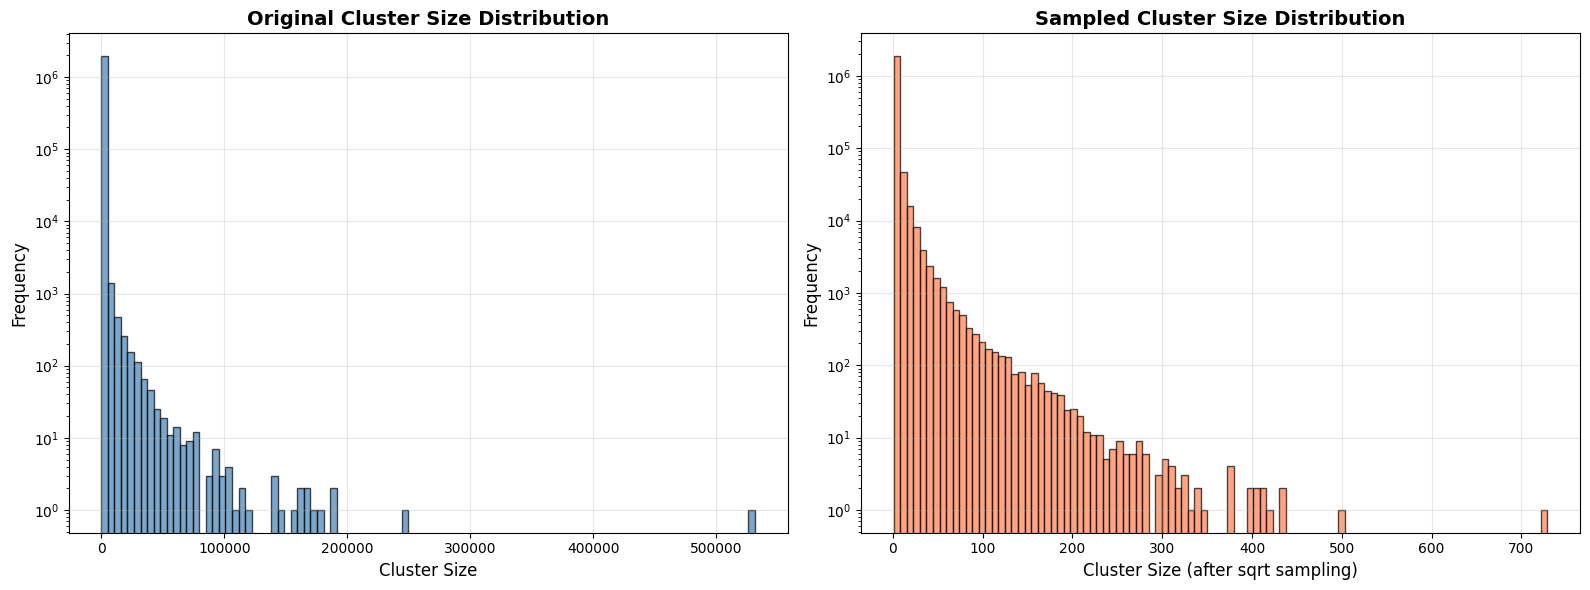

Total members - Original: 92,646,632, Sampled: 4,839,318
Sampling rate: 5.22%


In [20]:
import math

def get_sqrt_sampling_size(cluster_size):
    """
    Square root sampling strategy.
    For a cluster with N members, sample sqrt(N) members.
    Always keep at least 1 member.
    """
    if cluster_size <= 1:
        return cluster_size
    else:
        return max(1, int(math.sqrt(cluster_size)))


# Apply square root sampling
setup_seed(20000812)

sampled_sqrt_proteins = []
total_before_sqrt = 0
total_after_sqrt = 0

# Statistics by size range
sqrt_stats = {
    "1": {"before": 0, "after": 0},
    "2-5": {"before": 0, "after": 0},
    "6-10": {"before": 0, "after": 0},
    "11-50": {"before": 0, "after": 0},
    "51-100": {"before": 0, "after": 0},
    "101-500": {"before": 0, "after": 0},
    "501-1000": {"before": 0, "after": 0},
    ">1000": {"before": 0, "after": 0}
}

print("Applying square root sampling to clusters...")
for rep_id, mem_list in tqdm(cluster2member.items()):
    cluster_size = len(mem_list)
    sampling_size = get_sqrt_sampling_size(cluster_size)
    
    # Sample members
    members = mem_list if sampling_size >= cluster_size else random.sample(mem_list, sampling_size)
    sampled_sqrt_proteins += members
    
    total_before_sqrt += cluster_size
    total_after_sqrt += len(members)
    
    # Update statistics
    if cluster_size == 1:
        key = "1"
    elif 2 <= cluster_size <= 5:
        key = "2-5"
    elif 6 <= cluster_size <= 10:
        key = "6-10"
    elif 11 <= cluster_size <= 50:
        key = "11-50"
    elif 51 <= cluster_size <= 100:
        key = "51-100"
    elif 101 <= cluster_size <= 500:
        key = "101-500"
    elif 501 <= cluster_size <= 1000:
        key = "501-1000"
    else:
        key = ">1000"
    
    sqrt_stats[key]["before"] += cluster_size
    sqrt_stats[key]["after"] += len(members)

print(f"\n{'='*60}")
print(f"Square Root Sampling Results")
print(f"{'='*60}")
print(f"Total proteins before: {total_before_sqrt:,}")
print(f"Total proteins after: {total_after_sqrt:,}")
print(f"Overall sampling rate: {total_after_sqrt/total_before_sqrt*100:.2f}%")
print(f"\nDetailed statistics by cluster size range:")
print(f"{'Size Range':<15} {'Before':>12} {'After':>12} {'Rate':>8}")
print(f"{'-'*60}")
for size_range in ["1", "2-5", "6-10", "11-50", "51-100", "101-500", "501-1000", ">1000"]:
    before = sqrt_stats[size_range]["before"]
    after = sqrt_stats[size_range]["after"]
    rate = (after / before * 100) if before > 0 else 0
    print(f"{size_range:<15} {before:>12,} {after:>12,} {rate:>7.2f}%")


# Calculate sampled cluster sizes
sampled_cluster_sizes = [get_sqrt_sampling_size(len(mem_list)) for mem_list in cluster2member.values()]
original_cluster_sizes = [len(mem_list) for mem_list in cluster2member.values()]

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original distribution
axes[0].hist(original_cluster_sizes, bins=100, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Cluster Size', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Original Cluster Size Distribution', fontsize=14, fontweight='bold')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Sampled distribution
axes[1].hist(sampled_cluster_sizes, bins=100, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Cluster Size (after sqrt sampling)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Sampled Cluster Size Distribution', fontsize=14, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total members - Original: {sum(original_cluster_sizes):,}, Sampled: {sum(sampled_cluster_sizes):,}")
print(f"Sampling rate: {sum(sampled_cluster_sizes)/sum(original_cluster_sizes)*100:.2f}%")